In [3]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict


In [4]:
class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float

In [5]:
def calculate_bmi(state: BMIState) -> BMIState:
    state['bmi'] = round(state['weight'] / (state['height'] ** 2), 2)
    return state

In [7]:
# define the graph
graph = StateGraph(BMIState)
# add nodes to your graph
graph.add_node("calculate_bmi", calculate_bmi)
# add edges to your graph
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", END)
# compile the graph
workflow = graph.compile()

 

In [8]:
initial_state = {"weight": 80, "height": 1.75, "bmi": 0}
final_state = workflow.invoke(initial_state)
print(final_state)  # Output: {'weight': 80, 'height': 1.75, 'bmi': 26.12}

{'weight': 80, 'height': 1.75, 'bmi': 26.12}


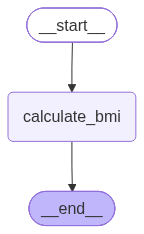

In [9]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())